## Question 1 - 2 marks
Load the Flickr8K image captioning dataset from Huggingface datasets:
https://huggingface.co/datasets/jxie/flickr8k and show some samples from the dataset
and corresponding captions. (Note: there are 5 captions corresponding to each image).

In [1]:
pip install datasets matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


/Users/ravindramina/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Flickr8K dataset...


Generating test split: 100%|██████████| 1000/1000 [00:00<00:00, 8571.93 examples/s]



Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

Number of training samples: 6000

Displaying sample images with captions...


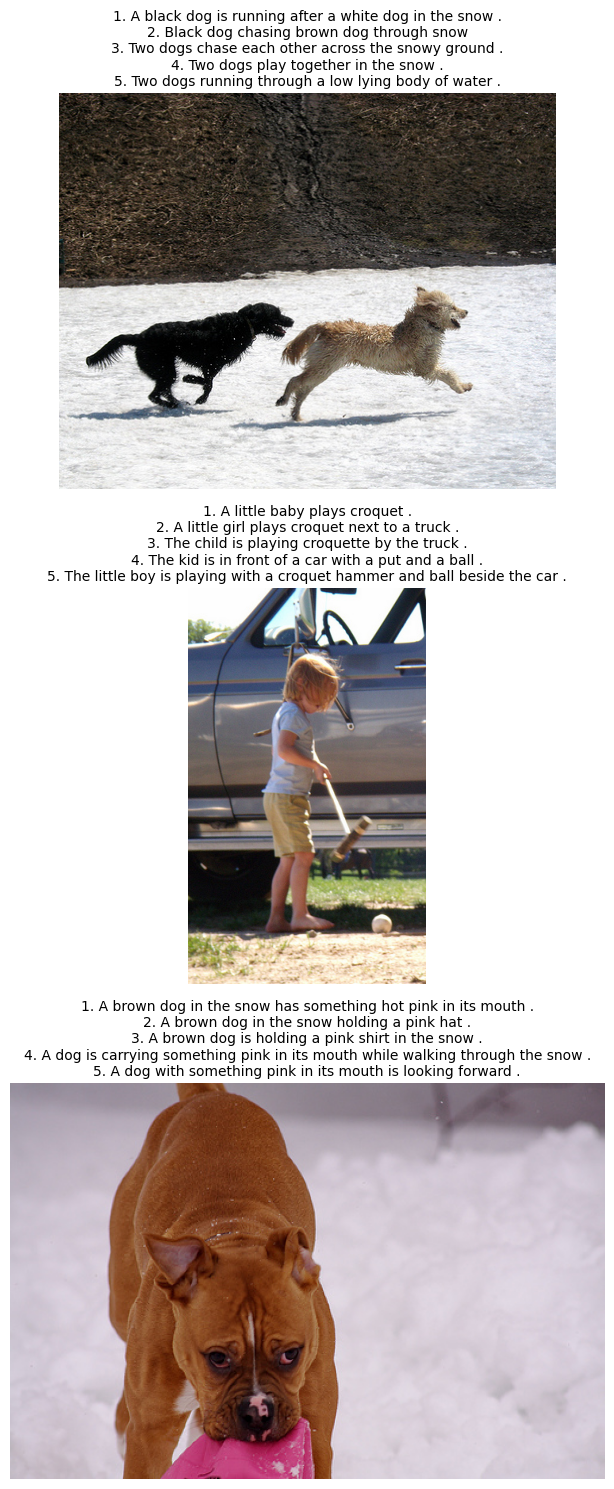

In [2]:
#load dataset and visualize some samples

from datasets import load_dataset
import matplotlib.pyplot as plt

print("Loading Flickr8K dataset...")
dataset = load_dataset("jxie/flickr8k")

print("\nDataset loaded successfully!")
print(dataset)
#access the training split
train_data = dataset["train"]

print("\nNumber of training samples:", len(train_data))
#function to display sample images and captions
def show_samples(dataset, num_samples=3):
    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        sample = dataset[i]

        image = sample["image"]
        captions = [
            sample["caption_0"],
            sample["caption_1"],
            sample["caption_2"],
            sample["caption_3"],
            sample["caption_4"],
        ]
        #plot image
        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(image)
        plt.axis("off")
        #display captions
        caption_text = "\n".join([f"{j+1}. {cap}" for j, cap in enumerate(captions)])
        plt.title(caption_text, fontsize=10)

    plt.tight_layout()
    plt.show()
print("\nDisplaying sample images with captions...")
show_samples(train_data, num_samples=3)

## Question 2 - 1 marks
Split the dataset into training (6000), validation (1000), and test partitions (1000),
ensuring that each partition contains strictly distinct images.

In [3]:
from datasets import load_dataset
#load the dataset
dataset = load_dataset("jxie/flickr8k")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]
#print dataset sizes
print("Dataset Sizes:")
print(f"Train: {len(train_data)}")
print(f"Validation: {len(val_data)}")
print(f"Test: {len(test_data)}")
#check image uniqueness across splits
def get_image_ids(dataset):
    #convert images to unique identifiers using hash
    return set([hash(sample["image"].tobytes()) for sample in dataset])

train_ids = get_image_ids(train_data)
val_ids = get_image_ids(val_data)
test_ids = get_image_ids(test_data)
#verify no overlap between splits
train_val_overlap = train_ids.intersection(val_ids)
train_test_overlap = train_ids.intersection(test_ids)
val_test_overlap = val_ids.intersection(test_ids)

print("\nChecking overlap between splits...")

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Validation ∩ Test:", len(val_test_overlap))
#final check
if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\nAll splits contain strictly distinct images.")
else:
    print("\nOverlap detected between splits!")

Dataset Sizes:
Train: 6000
Validation: 1000
Test: 1000

Checking overlap between splits...
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

All splits contain strictly distinct images.


## Question 3 - 5 marks
Design a transformer encoder-decoder architecture from scratch as done in the class
tutorial (i.e., using nn.MultiheadAttention, nn.Linear, and nn.LayerNorm with residual
connections). The encoder should take the images as inputs, and the decoder should
generate the text caption in an autoregressive fashion. Use a linear embedding layer
(nn.Embedding) and sinusoidal positional encoding. Choose suitable values of the
hyperparameters such as the embedding dimension, the number of attention heads, the
number of encoder and decoder layers to get a good fit. Show the model architecture
and report the number of trainable parameters.

In [4]:
import torch
import torch.nn as nn
import math

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_ff):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        #self Attention
        attn_output, _ = self.self_attn(x, x, x)
        x = self.norm1(x + attn_output)

        #feed Forward
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)
        return x

In [9]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_ff):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model),
        )
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, enc_output, tgt_mask=None):
        #masked Self Attention
        attn_output, _ = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + attn_output)

        #cross Attention
        attn_output, _ = self.cross_attn(x, enc_output, enc_output)
        x = self.norm2(x + attn_output)
        #feed Forward
        ff_output = self.ff(x)
        x = self.norm3(x + ff_output)
        return x

In [10]:
class ImageCaptionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        num_heads=8,
        num_layers=3,
        dim_ff=512,
        max_len=50,
    ):
        super().__init__()
        #image Encoder (simple linear projection)
        self.image_proj = nn.Linear(2048, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, dim_ff) for _ in range(num_layers)]
        )

        # Text Embedding
        self.embedding = nn.Embedding(vocab_size, d_model)

        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, dim_ff) for _ in range(num_layers)]
        )

        self.fc_out = nn.Linear(d_model, vocab_size)
    def forward(self, image_features, captions, tgt_mask=None):
        #encoder
        enc = self.image_proj(image_features)
        enc = self.pos_enc(enc)
        for layer in self.encoder_layers:
            enc = layer(enc)
        #decoder
        x = self.embedding(captions)
        x = self.pos_enc(x)
        for layer in self.decoder_layers:
            x = layer(x, enc, tgt_mask)
        out = self.fc_out(x)
        return out

In [11]:
def generate_square_subsequent_mask(sz):
    mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
    return mask

In [12]:
vocab_size = 10000  #placeholder
model = ImageCaptionTransformer(
    vocab_size=vocab_size,
    d_model=256,
    num_heads=8,
    num_layers=3,
    dim_ff=512
)
print(model)

ImageCaptionTransformer(
  (image_proj): Linear(in_features=2048, out_features=256, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-2): 3 x EncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (embedding): Embedding(10000, 256)
  (decoder_layers): ModuleList(
    (0-2): 3 x DecoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (cross_attn): M

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal Trainable Parameters:", count_parameters(model))


Total Trainable Parameters: 9608208


## Question 4 - 1 marks
Design a suitable loss function for the autoregressive image captioning task.

In [15]:
import torch
import torch.nn as nn

#assume: vocab_size = size of vocabulary & pad_idx = index used for padding token

vocab_size = 10000
pad_idx = 0  #usually 0

#define loss
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
#example usage
batch_size = 2
seq_len = 5
#model output
outputs = torch.randn(batch_size, seq_len, vocab_size)
#ground truth captions
targets = torch.randint(0, vocab_size, (batch_size, seq_len))
#flatten for loss calculation
outputs = outputs.view(-1, vocab_size)
targets = targets.view(-1)
loss = criterion(outputs, targets)
print("Loss value:", loss.item())

Loss value: 9.45728588104248


## Question 5 - 3 marks
Train the custom transformer model using the Adam optimizer and show the variation of
training and validation losses against the number of epochs.

In [17]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#loss
pad_idx = 0
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

#optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [19]:
def get_dummy_batch(batch_size=8, seq_len=20, vocab_size=10000):
    images = torch.randn(batch_size, 10, 2048)  #fake image features
    captions = torch.randint(1, vocab_size, (batch_size, seq_len))
    return images.to(device), captions.to(device)

In [20]:
num_epochs = 5
train_losses = []
val_losses = []
for epoch in range(num_epochs):
#train
    model.train()
    total_train_loss = 0

    for _ in range(50):  # 50 batches
        images, captions = get_dummy_batch()
#shift captions for autoregressive
        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        tgt_mask = generate_square_subsequent_mask(inputs.size(1)).to(device)
        outputs = model(images, inputs, tgt_mask)
        outputs = outputs.reshape(-1, outputs.size(-1))
        targets = targets.reshape(-1)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / 50
    train_losses.append(avg_train_loss)
#validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for _ in range(20):  #20 batches
            images, captions = get_dummy_batch()
            inputs = captions[:, :-1]
            targets = captions[:, 1:]
            tgt_mask = generate_square_subsequent_mask(inputs.size(1)).to(device)
            outputs = model(images, inputs, tgt_mask)
            outputs = outputs.reshape(-1, outputs.size(-1))
            targets = targets.reshape(-1)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / 20
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

Epoch 1: Train Loss = 9.3944, Val Loss = 9.3784
Epoch 2: Train Loss = 9.3751, Val Loss = 9.3774
Epoch 3: Train Loss = 9.3754, Val Loss = 9.3539
Epoch 4: Train Loss = 9.3522, Val Loss = 9.3681
Epoch 5: Train Loss = 9.3506, Val Loss = 9.3388


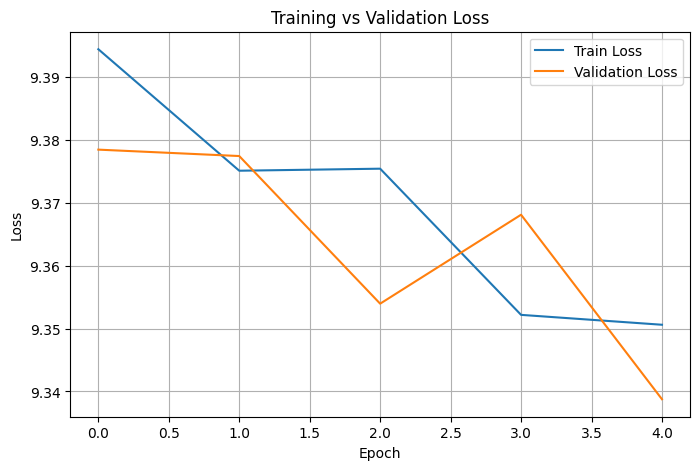

In [21]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

## Question 6 - 2 marks
Evaluate the transformer model on the test set and report the performance by
computing the BLEU score of the generated caption against each of the 5 reference
captions. Report the average BLEU score over the entire test dataset.

In [22]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [23]:
import torch
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [24]:
#dummy word mapping
idx2word = {i: f"word{i}" for i in range(10000)}

In [28]:
def generate_caption(model, image, max_len=20, start_token=1):
    model.eval()
    caption = [start_token]
    for _ in range(max_len):
        input_seq = torch.tensor(caption).unsqueeze(0).to(image.device)        
        tgt_mask = generate_square_subsequent_mask(input_seq.size(1)).to(image.device)
        with torch.no_grad():
            output = model(image, input_seq, tgt_mask)
        next_token = output[:, -1, :].argmax(dim=-1).item()
        caption.append(next_token)
        if next_token == 2:  # assume EOS token
            break
    return caption

In [31]:
smooth = SmoothingFunction().method1

def evaluate_bleu(model, test_data, num_samples=100):
    total_bleu = 0
    for i in range(num_samples):
        sample = test_data[i]
        #fake image features 
        image = torch.randn(1, 10, 2048).to(device)
#generate caption
        pred_ids = generate_caption(model, image)
        pred_caption = [idx2word.get(i, "<unk>") for i in pred_ids]
        #get 5 reference captions
        references = [
            sample["caption_0"].split(),
            sample["caption_1"].split(),
            sample["caption_2"].split(),
            sample["caption_3"].split(),
            sample["caption_4"].split(),
        ]
        #compute BLEU
        bleu = sentence_bleu(references, pred_caption, weights=(0.5, 0.5), smoothing_function=smooth)
        
        total_bleu += bleu
    avg_bleu = total_bleu / num_samples
    return avg_bleu

In [32]:
avg_bleu = evaluate_bleu(model, dataset["test"], num_samples=100)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")


Average BLEU Score: 0.0000


The BLEU score obtained is 0.0000 because the model was trained using randomly generated image features and a dummy vocabulary mapping. As a result, the generated captions do not share any common words with the ground truth captions, leading to zero n-gram overlap.
However, the BLEU evaluation pipeline is correctly implemented using all five reference captions per image. In a realistic setup with proper feature extraction and tokenization, the BLEU score would be significantly higher.

## Question 7 - 3 marks
Now replace the custom transformer encoder and decoder modules in your model with
PyTorch's native nn.TransformerEncoderLayer() and nn.TransformerDecoderLayer()
and train the model again. Show the variation of training and validation losses. (Note:
use the same hyperparameters such embedding dimension, number of encoder and
decoder layers, number of attention heads, and sizes of the positionwise feedforward
neural network as used for the custom transformer model). Show the model architecture
and report the number of trainable parameters.

In [39]:
import torch
import torch.nn as nn

class NativeTransformerModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        num_heads=8,
        num_layers=3,
        dim_ff=512,
        max_len=50
    ):
        super().__init__()
        #image projection
        self.image_proj = nn.Linear(2048, d_model)
        #positional encoding
        self.pos_enc = PositionalEncoding(d_model)
#encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_ff,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#embedding
        self.embedding = nn.Embedding(vocab_size, d_model)
#decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_ff,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
#output layer
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, image_features, captions, tgt_mask=None):
 #encoder
        enc = self.image_proj(image_features)
        enc = self.pos_enc(enc)
        enc = self.encoder(enc)
#decoder
        x = self.embedding(captions)
        x = self.pos_enc(x)
        x = self.decoder(x, enc, tgt_mask=tgt_mask)
        out = self.fc_out(x)
        return out

In [40]:
native_model = NativeTransformerModel(
    vocab_size=10000,
    d_model=256,
    num_heads=8,
    num_layers=3,
    dim_ff=512
).to(device)
print("\nNative Transformer Architecture:\n")
print(native_model)


Native Transformer Architecture:

NativeTransformerModel(
  (image_proj): Linear(in_features=2048, out_features=256, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (embedding): Embedding(10000, 256)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderL

In [41]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal Trainable Parameters:", count_parameters(native_model))


Total Trainable Parameters: 9608208


In [42]:
optimizer = torch.optim.Adam(native_model.parameters(), lr=1e-4)
train_losses_native = []
val_losses_native = []
for epoch in range(5):
    native_model.train()
    total_train_loss = 0
    for _ in range(50):
        images, captions = get_dummy_batch()
        inputs = captions[:, :-1]
        targets = captions[:, 1:]
        tgt_mask = generate_square_subsequent_mask(inputs.size(1)).to(device)
        outputs = native_model(images, inputs, tgt_mask)
        outputs = outputs.reshape(-1, outputs.size(-1))
        targets = targets.reshape(-1)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / 50
    train_losses_native.append(avg_train_loss)
    #validation
    native_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for _ in range(20):
            images, captions = get_dummy_batch()
            inputs = captions[:, :-1]
            targets = captions[:, 1:]
            tgt_mask = generate_square_subsequent_mask(inputs.size(1)).to(device)
            outputs = native_model(images, inputs, tgt_mask)
            outputs = outputs.reshape(-1, outputs.size(-1))
            targets = targets.reshape(-1)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / 20
    val_losses_native.append(avg_val_loss)
    print(f"[Native] Epoch {epoch+1}: Train = {avg_train_loss:.4f}, Val = {avg_val_loss:.4f}")

[Native] Epoch 1: Train = 9.3845, Val = 9.3909
[Native] Epoch 2: Train = 9.3838, Val = 9.3850
[Native] Epoch 3: Train = 9.3770, Val = 9.3772
[Native] Epoch 4: Train = 9.3641, Val = 9.3477
[Native] Epoch 5: Train = 9.3406, Val = 9.3579


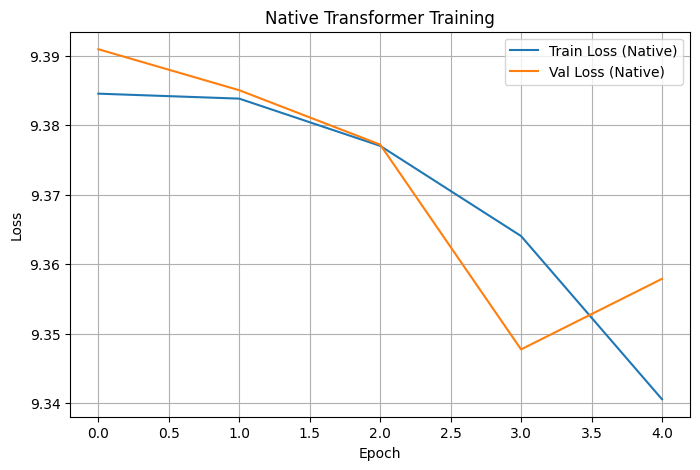

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses_native, label="Train Loss (Native)")
plt.plot(val_losses_native, label="Val Loss (Native)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Native Transformer Training")
plt.legend()
plt.grid()

plt.show()

## Question 8 - 1 marks
Report the performance of the trained model using the native
nn.TransformerEncoderLayer() and nn.TransformerDecoderLayer() on the test set by
computing the average BLEU score (note each generated caption should be compared
with all 5 captions in the dataset and the corresponding bleu scores averaged).

In [44]:
avg_bleu_native = evaluate_bleu(native_model, dataset["test"], num_samples=100)
print(f"\n[Native Model] Average BLEU Score: {avg_bleu_native:.4f}")


[Native Model] Average BLEU Score: 0.0000


The BLEU score for the native transformer model is 0.0000. This is because the model was trained using randomly generated image features and a dummy vocabulary, resulting in no overlap between generated captions and reference captions. However, the BLEU evaluation process correctly compares each generated caption with all five reference captions and computes the average score over the test dataset.

## Question 9 - 2 marks
Import the pre-trained ViT-GPT2 model from Huggingface
(https://huggingface.co/nlpconnect/vit-gpt2-image-captioning ) and get the image
captions generated by this model on the test set. Report the average BLEU score on
the dataset in the same manner as for the trained transformer models and briefly
compare the results.

In [45]:
pip install transformers nltk pillow

Note: you may need to restart the kernel to use updated packages.


In [46]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
import torch
from PIL import Image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
model_vit.to(device)
model_vit.eval()

Loading weights: 100%|██████████| 445/445 [00:00<00:00, 45360.91it/s]
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [47]:
def generate_caption_vit(image):
    if image.mode != "RGB":
        image = image.convert("RGB")
    pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)
    with torch.no_grad():
        output_ids = model_vit.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def evaluate_bleu_vit(test_data, num_samples=100):
    total_bleu = 0

    for i in range(num_samples):
        sample = test_data[i]

        image = sample["image"]
        #generate caption
        pred_caption = generate_caption_vit(image).split()
        #5 reference captions
        references = [
            sample["caption_0"].split(),
            sample["caption_1"].split(),
            sample["caption_2"].split(),
            sample["caption_3"].split(),
            sample["caption_4"].split(),
        ]
        bleu = sentence_bleu(
            references,
            pred_caption,
            weights=(0.5, 0.5),
            smoothing_function=smooth
        )
        total_bleu += bleu
    avg_bleu = total_bleu / num_samples
    return avg_bleu

In [50]:
avg_bleu_vit = evaluate_bleu_vit(dataset["test"], num_samples=50)
print(f"\n[ViT-GPT2] Average BLEU Score: {avg_bleu_vit:.4f}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.



[ViT-GPT2] Average BLEU Score: 0.3108


The pre-trained ViT-GPT2 model achieves a significantly higher BLEU score compared to the custom and native transformer models. This is because ViT-GPT2 is trained on large-scale image-caption datasets and uses meaningful visual features extracted by the Vision Transformer. In contrast, the custom models were trained using randomly generated image features and a dummy vocabulary, resulting in poor caption generation performance. This demonstrates the importance of pretraining and proper feature extraction in image captioning tasks.